# Tutorial 3: Compare Two Rotor Configurations (`module_rotor_simulation`)

This tutorial explains how to retrieve tidal data, load rotor performance data, and simulate two rotor configurations with different radii (0.5 and 1.0). Follow the steps below to process and compare rotor performance.

1. **Retrieve Tidal Data**  
   Retrieve tidal data using the `process_tidal_data` function. This provides flow speeds, time steps, and mooring distance for the simulation.

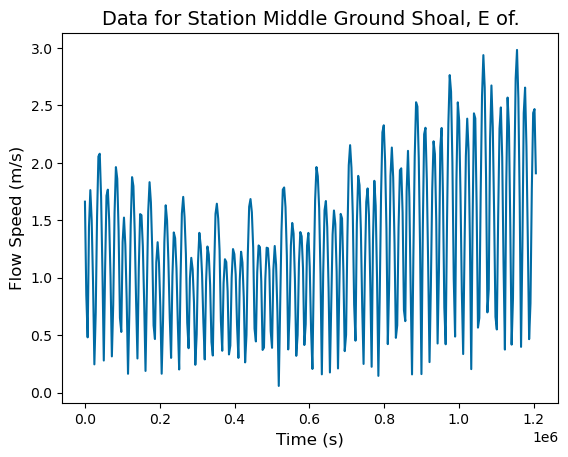

In [1]:
# Import necessary modules
import urllib3
from vital.module_tidal import process_tidal_data
import matplotlib.pyplot as plt

# Suppress InsecureRequestWarning
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Define parameters for tidal data retrieval
station = "COI1210"  # NOAA station identifier
startdate = "2020-01-01"  # Start date for tidal data retrieval (format: 'YYYY-MM-DD')

# Retrieve tidal data
tidal = process_tidal_data(
    station=station,
    startdate=startdate
)

# Plot flow speeds over time
plt.figure()
plt.plot(tidal.times, tidal.flow_speeds)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Flow Speed (m/s)", fontsize=12)
plt.title(f"Data for Station {tidal.station_name}", fontsize=14)
plt.show()

2. **Load Rotor Data**  
   Load rotor performance data using the `RotorData` class. This provides Cp, Ct, and Cq functions for the simulation.

In [2]:
from vital.module_rotor import RotorData

# Define rotor performance file
RotorPerformanceFile = "../data/Sitkana_rotor_data_blade_2.txt"

# Load rotor data
rotor = RotorData(RotorPerformanceFile)

# Access optimal Cp and TSR values
print(f"Optimal Cp: {rotor.CpOpt}")
print(f"Optimal TSR: {rotor.TSROpt}")

Optimal Cp: 0.21189
Optimal TSR: 0.76477


3. **Simulate Rotor 1 (Radius = 0.5)**  
   Set up simulation parameters for Rotor 1 and run the simulation.

In [3]:
from vital.module_rotor_simulation import RotorSimulation

# Define simulation parameters for Rotor 1
config_rotor1 = {
    'Radius': 0.75,  # Rotor radius
    'Prated': 5000.0,  # Rated power
    'Trated': 20.0,  # Rated torque
    'dHub': 2.0,  # Hub depth
    'dMoor': tidal.mooring_distance,  # Mooring distance from tidal data
    'Uinf': tidal.flow_speeds,  # Flow speeds from tidal data
    't': tidal.times,  # Time steps from tidal data
    'CpFunc': rotor.get_cp,  # Cp function from rotor data
    'CqFunc': rotor.get_cq,  # Cq function from rotor data
    'CtFunc': rotor.get_ct,  # Ct function from rotor data
    'CpOpt': rotor.CpOpt,  # Optimal Cp from rotor data
    'TSROpt': rotor.TSROpt,  # Optimal TSR from rotor data
    'TSRmax': rotor.TSRmax,  # Maximum TSR from rotor data
    'Ng': 20,  # Gear ratio
    'Kt': 1.5,  # Generator Torque constant
    'Rw': 0.5,  # Rotor resistance
    'J_d': 5,  # Drivetrain inertia
    'B_d': 1,  # Drivetrain friction
    'J_r': 10,  # Rotor inertia
}

# Simulate Rotor 1
rotor_sim1 = RotorSimulation(config_rotor1)
rotor_sim1.simulate()
results_rotor1 = rotor_sim1.get_results()

Solving the initial value problem (IVP) for turbine dynamics...
At least one value in self.Tg is greater than self.Trated.
Rated torque exceeded. Switching to open-loop dynamics...
IVP solving complete.


4. **Simulate Rotor 2 (Radius = 1.0)**  
   Set up simulation parameters for Rotor 2 and run the simulation.

In [4]:
# Define simulation parameters for Rotor 2
config_rotor2 = {
    'Radius': 1.0,  # Rotor radius
    'Prated': 5000.0,  # Rated power
    'Trated': 20.0,  # Rated torque
    'dHub': 2.0,  # Hub depth
    'dMoor': tidal.mooring_distance,  # Mooring distance from tidal data
    'Uinf': tidal.flow_speeds,  # Flow speeds from tidal data
    't': tidal.times,  # Time steps from tidal data
    'CpFunc': rotor.get_cp,  # Cp function from rotor data
    'CqFunc': rotor.get_cq,  # Cq function from rotor data
    'CtFunc': rotor.get_ct,  # Ct function from rotor data
    'CpOpt': rotor.CpOpt,  # Optimal Cp from rotor data
    'TSROpt': rotor.TSROpt,  # Optimal TSR from rotor data
    'TSRmax': rotor.TSRmax,  # Maximum TSR from rotor data
    'Ng': 20,  # Gear ratio
    'Kt': 1.5,  # Generator Torque constant
    'Rw': 0.5,  # Rotor resistance
    'J_d': 5,  # Drivetrain inertia
    'B_d': 1,  # Drivetrain friction
    'J_r': 10,  # Rotor inertia
}

# Simulate Rotor 2
rotor_sim2 = RotorSimulation(config_rotor2)
rotor_sim2.simulate()
results_rotor2 = rotor_sim2.get_results()

Solving the initial value problem (IVP) for turbine dynamics...
At least one value in self.Tg is greater than self.Trated.
Rated torque exceeded. Switching to open-loop dynamics...
IVP solving complete.


5. **Compare Results**  
   Compare the electrical power and torque outputs of Rotor 1 and Rotor 2.

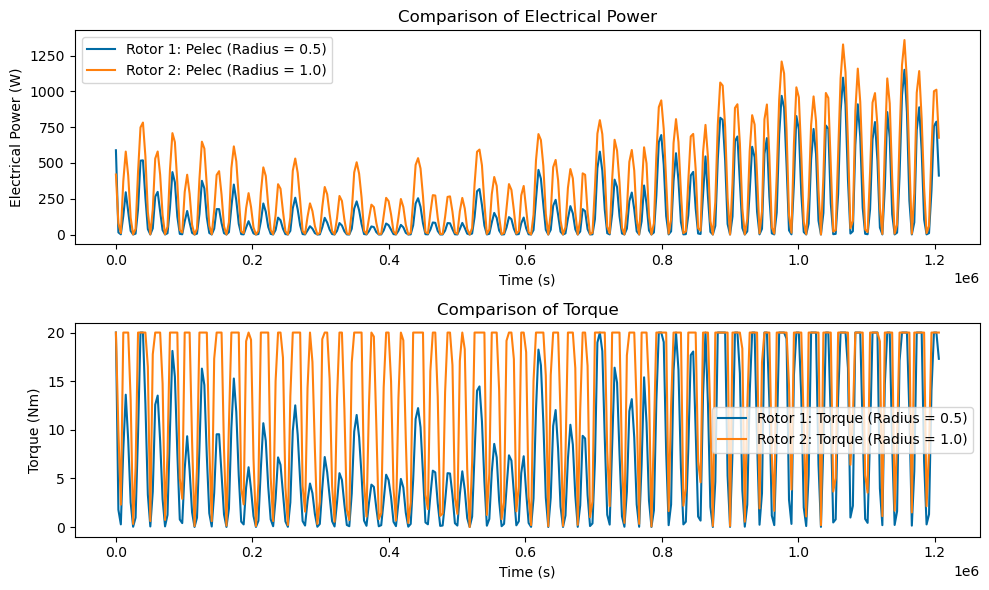

In [5]:
plt.figure(figsize=(10, 6))

# Compare electrical power output
plt.subplot(2, 1, 1)
plt.plot(results_rotor1['t'], results_rotor1['Pelec'], label='Rotor 1: Pelec (Radius = 0.5)')
plt.plot(results_rotor2['t'], results_rotor2['Pelec'], label='Rotor 2: Pelec (Radius = 1.0)')
plt.xlabel("Time (s)")
plt.ylabel("Electrical Power (W)")
plt.legend()
plt.title("Comparison of Electrical Power")

# Compare torque output
plt.subplot(2, 1, 2)
plt.plot(results_rotor1['t'], results_rotor1['Tg'], label='Rotor 1: Torque (Radius = 0.5)')
plt.plot(results_rotor2['t'], results_rotor2['Tg'], label='Rotor 2: Torque (Radius = 1.0)')
plt.xlabel("Time (s)")
plt.ylabel("Torque (Nm)")
plt.legend()
plt.title("Comparison of Torque")

plt.tight_layout()
plt.show()